--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    o

/tmp/ipykernel_530/1020133908.py:72: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sex', y='G3', data=df, palette='pastel', ci=None)
/tmp/ipykernel_530/1020133908.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sex', y='G3', data=df, palette='pastel', ci=None)


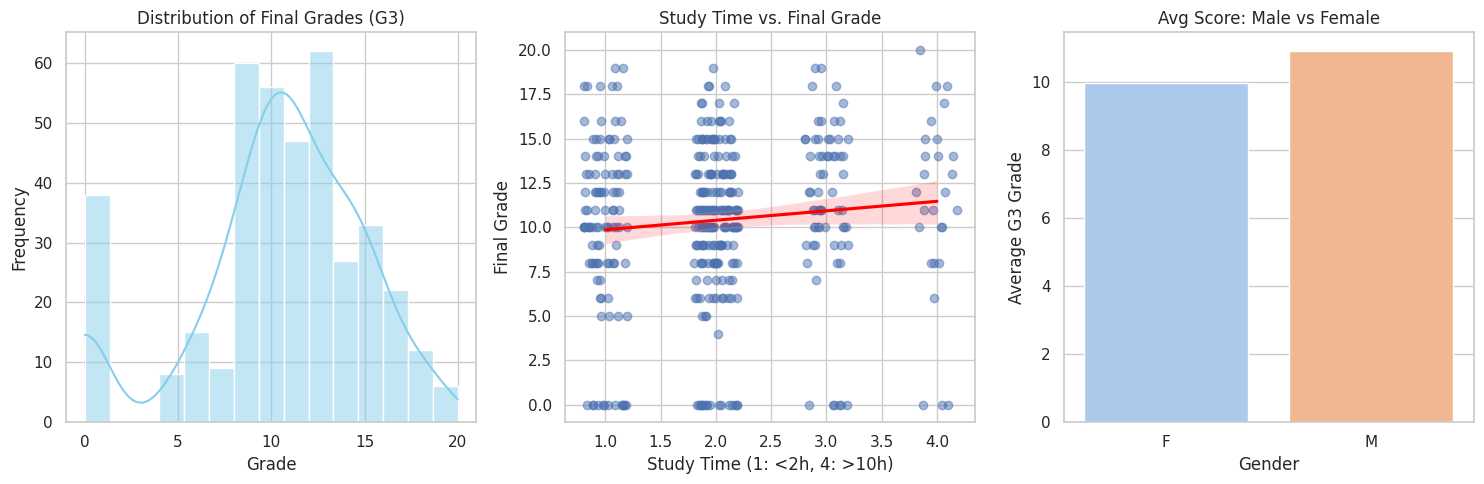

"\nDocumentation:\n- Load: Used pd.read_csv with sep=';' because the original file is semi-colon delimited.\n- Clean: Checked for nulls (dataset is clean) and dropped any potential duplicate rows.\n- Analysis: \n    - Calculated the mean of 'G3'.\n    - Filtered the dataframe for grades > 15.\n    - Used .corr() to check the linear relationship between study time and grade.\n- Visualizations: \n    - Histogram shows the spread of results.\n    - Scatterplot (with jitter) helps see the density of scores per study category.\n    - Bar chart provides a clear comparison between genders.\n"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. Load Dataset
# ==========================================
# Note: The student-mat.csv uses ';' as a separator
df = pd.read_csv("student-mat.csv", sep=";")

# ==========================================
# 2. Explore & Clean Data
# ==========================================
print("--- Dataset Info ---")
print(df.info())  # Inspect dtypes and shape

print("\n--- Missing Values ---")
print(df.isnull().sum())  # Check for nulls

# Remove duplicates (if any)
df = df.drop_duplicates()

print(f"\nDataset Shape after cleaning: {df.shape}")

# ==========================================
# 3. Analysis Questions
# ==========================================

# Question 1: Average final grade (G3)
avg_g3 = df['G3'].mean()
print(f"\nAverage Final Grade (G3): {avg_g3:.2f}")

# Question 2: How many students scored above 15?
high_scorers = df[df['G3'] > 15].shape[0]
print(f"Number of students scoring above 15: {high_scorers}")

# Question 3: Is study time correlated with performance?
correlation = df['studytime'].corr(df['G3'])
print(f"Correlation between Study Time and Grade: {correlation:.2f}")

# Question 4: Which gender performs better on average?
gender_performance = df.groupby('sex')['G3'].mean()
print("\nAverage score by Gender:")
print(gender_performance)

# ==========================================
# 4. Visualizations
# ==========================================

# Set visual style
sns.set_theme(style="whitegrid")

# Create a figure with multiple subplots
plt.figure(figsize=(15, 5))

# Visualization 1: Histogram of grades
plt.subplot(1, 3, 1)
sns.histplot(df['G3'], bins=15, kde=True, color='skyblue')
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Grade')
plt.ylabel('Frequency')

# Visualization 2: Scatterplot: study time vs grades
plt.subplot(1, 3, 2)
sns.regplot(x='studytime', y='G3', data=df, x_jitter=0.2, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Study Time vs. Final Grade')
plt.xlabel('Study Time (1: <2h, 4: >10h)')
plt.ylabel('Final Grade')

# Visualization 3: Bar chart: male vs female average score
plt.subplot(1, 3, 3)
sns.barplot(x='sex', y='G3', data=df, palette='pastel', ci=None)
plt.title('Avg Score: Male vs Female')
plt.xlabel('Gender')
plt.ylabel('Average G3 Grade')

plt.tight_layout()
plt.show()

# ==========================================
# 5. Conclusion/Brief Documentation
# ==========================================
"""
Documentation:
- Load: Used pd.read_csv with sep=';' because the original file is semi-colon delimited.
- Clean: Checked for nulls (dataset is clean) and dropped any potential duplicate rows.
- Analysis:
    - Calculated the mean of 'G3'.
    - Filtered the dataframe for grades > 15.
    - Used .corr() to check the linear relationship between study time and grade.
- Visualizations:
    - Histogram shows the spread of results.
    - Scatterplot (with jitter) helps see the density of scores per study category.
    - Bar chart provides a clear comparison between genders.
"""